In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

## I can now load directly from src via my .toml file.
from src.data import remove_zero_variance, load_data


## Get data
X_df, y_df = load_data()



KeyboardInterrupt: 

Lets test logistic regression first for classification.

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

## Load the training data
X_train, X_test, y_train, y_test = train_test_split(X_df, y_df, test_size = 0.2, stratify = y_df, random_state = 42)

## Set model
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=2000))
])

## Need to define hyperparameter grid for GridSearchCV

param_grid = {'classifier__C' : [0.001, 0.01, 0.1, 1.0, 10.0]}

grid_search =  GridSearchCV(
    estimator = pipeline, param_grid = param_grid, 
    cv = 5, scoring = 'accuracy', error_score="raise")


## Fit model
grid_search.fit(X_train, y_train)

## Get predictions
y_pred = grid_search.predict(X_test)

## Calculate and display accuracy metrics
logreg_accuracy = accuracy_score(y_test, y_pred)
logreg_report = classification_report(y_test, y_pred)
logreg_cv_accuracy = grid_search.best_score_

print(logreg_accuracy)
print("Best parameters:", grid_search.best_params_)
print("Best CV accuracy:", grid_search.best_score_)
print(logreg_report)

print("Best parameters:", grid_search.best_params_)
print("Best CV accuracy:", grid_search.best_score_)

#Best parameters: {'classifier__C': 0.001}
#Best CV accuracy: 0.9984375


0.9875776397515528
Best parameters: {'classifier__C': 0.001}
Best CV accuracy: 0.9984375
              precision    recall  f1-score   support

        BRCA       0.98      1.00      0.99        60
        COAD       1.00      0.94      0.97        16
        KIRC       1.00      1.00      1.00        30
        LUAD       0.96      0.96      0.96        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           0.99       161
   macro avg       0.99      0.98      0.98       161
weighted avg       0.99      0.99      0.99       161

Best parameters: {'classifier__C': 0.001}
Best CV accuracy: 0.9984375


Wow logistic regression achieved 98.8% accuracy on test set. Now lets see if random forest does any better. It will at least let me pull out the genes that are most informative in the classification. 

In [ ]:
from sklearn.ensemble import RandomForestClassifier

## Load the training data
X_train, X_test, y_train, y_test = train_test_split(X_df, y_df, test_size = 0.2, stratify = y_df, random_state = 42)

## Initiate a pipeline. Scaling does not matter for randome forest 
## so I will leave it out of pipeline for now


rf_pipeline = Pipeline([
    ("classifier", RandomForestClassifier(random_state=42))
])

## Define param grid
param_grid = {
    "classifier__n_estimators": [100, 300, 500],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_leaf": [1, 2, 5],
}

rf_grid_search =  GridSearchCV(
    estimator = rf_pipeline, param_grid = param_grid, 
    cv = 5, scoring = 'accuracy', error_score="raise", n_jobs=-1)

## Fit model
rf_grid_search .fit(X_train, y_train)

## Get predictions
y_pred = rf_grid_search.predict(X_test)

## Calculate and display accuracy metrics
rf_accuracy = accuracy_score(y_test, y_pred)
rf_report = classification_report(y_test, y_pred)
rf_cv_accuracy = rf_grid_search.best_score_
print("Test: ", rf_accuracy)
print("Best parameters:", rf_grid_search.best_params_)
print("Best CV accuracy:", rf_grid_search.best_score_)
print(rf_report)



/Users/shanewarland/miniforge3/envs/cancer-ml/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Test:  0.9937888198757764
Best parameters: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 100}
Best CV accuracy: 0.996875
              precision    recall  f1-score   support

        BRCA       0.98      1.00      0.99        60
        COAD       1.00      1.00      1.00        16
        KIRC       1.00      1.00      1.00        30
        LUAD       1.00      0.96      0.98        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           0.99       161
   macro avg       1.00      0.99      0.99       161
weighted avg       0.99      0.99      0.99       161



In [ ]:
print(type(grid_search.best_estimator_))

<class 'sklearn.pipeline.Pipeline'>


Ok now lets try XGboost. Quite hard to imrpove 99.37% accuracy

In [ ]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

## Load the training data
X_train, X_test, y_train, y_test = train_test_split(X_df, y_df, test_size = 0.2, stratify = y_df, random_state = 42)

## Initiate a pipeline. Scaling does not matter for randome forest 
## so I will leave it out of pipeline for now

xgb_pipeline = Pipeline([
    ("classifier", XGBClassifier(random_state=42))
])

## Define param grid
param_grid = {
    "classifier__n_estimators": [50, 100],
    "classifier__max_depth": [3, 5, 7],
    "classifier__learning_rate": [0.01, 0.1, 1],
}

grid_search =  GridSearchCV(
    estimator = xgb_pipeline, param_grid = param_grid, 
    cv = 5, scoring = 'accuracy', error_score="raise", n_jobs=-1)

## One last thing. XGBoost cannot use string labels
le = LabelEncoder()
y_numeric = le.fit_transform(y_train)

## Fit model
grid_search.fit(X_train, y_numeric)

## Get predictions
predictions = grid_search.predict(X_test)
y_pred = le.inverse_transform(predictions) ## undo the encoding

## Calculate and display accuracy metrics
xgb_accuracy = accuracy_score(y_test, y_pred)
xgb_report = classification_report(y_test, y_pred)
xgb_cv_accuracy = grid_search.best_score_
print("Test: ", xgb_accuracy)
print("Best parameters:", grid_search.best_params_)
print("Best CV accuracy:", grid_search.best_score_)
print(xgb_report)

/Users/shanewarland/miniforge3/envs/cancer-ml/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Test:  0.9813664596273292
Best parameters: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 50}
Best CV accuracy: 0.990625
              precision    recall  f1-score   support

        BRCA       0.95      1.00      0.98        60
        COAD       1.00      0.88      0.93        16
        KIRC       1.00      1.00      1.00        30
        LUAD       1.00      0.96      0.98        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           0.98       161
   macro avg       0.99      0.97      0.98       161
weighted avg       0.98      0.98      0.98       161



In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "CV Accuracy": [
        logreg_cv_accuracy,
        rf_cv_accuracy,
        xgb_cv_accuracy 
    ],
    "Test Accuracy": [
        logreg_accuracy,
        rf_accuracy,
        xgb_accuracy
    ]
})

print(results)

results.to_csv('../figures/results.csv', index=False)

                 Model  CV Accuracy  Test Accuracy
0  Logistic Regression     0.998437       0.987578
1        Random Forest     0.996875       0.993789
2              XGBoost     0.990625       0.981366


Ok Random Forest won. Although they were all so close. Logistic regression is much faster so that's worth considering. XGBoost took a while on my computer. 

We are now going to use my top performing model, Random forest, to calculate the SHAP (Shapely Additive Predictions) to determine which genes were most informative in predicting the different disease classifications. This is better than just using random forests feature selections as it is specific for the patient. SHAP provides ranking of genes per patient whereas RF features are averages. 

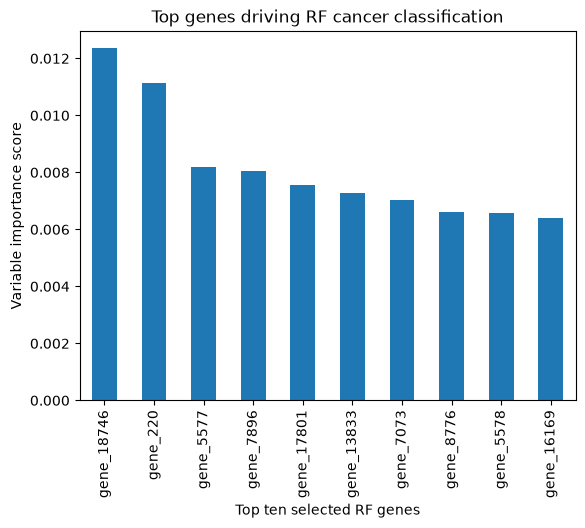

In [118]:
best_pipeline = rf_grid_search.best_estimator_

rf_model = best_pipeline.named_steps["classifier"]
rf_model.feature_importances_
importances = pd.Series(rf_model.feature_importances_, index=X_df.columns)

sorted_importances = importances.sort_values(ascending = False)
top_ten_genes = sorted_importances.head(10)
top_gene = top_ten_genes.index[0]

top_ten_genes.plot.bar()
plt.xlabel("Top ten selected RF genes")
plt.ylabel("Variable importance score")
plt.title("Top genes driving RF cancer classification")
plt.show()

The following are the possible cancer classifications: ['BRCA' 'COAD' 'KIRC' 'LUAD' 'PRAD']
The predicted disease for patient 1 was KIRC


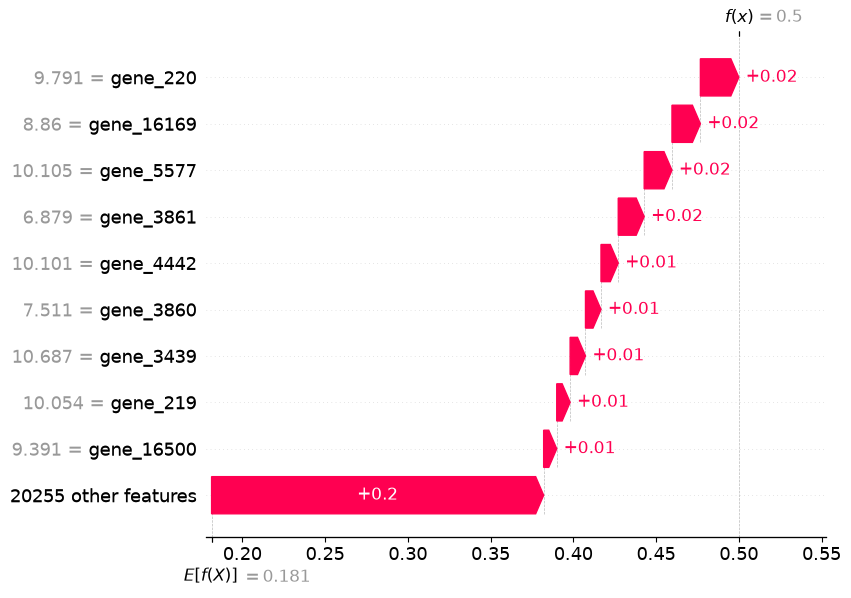

In [147]:
## Ok lets try using SHAP for this

import shap

print(f"The following are the possible cancer classifications: {rf_model.classes_}") 
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer(X_test)

## Ok for patient 1 what was the predicted disease type
pred_class = rf_model.predict(X_test.iloc[[0]])[0]
print(f"The predicted disease for patient 1 was {pred_class}")

## genes that most influenced the KIRK disease state prediction shown via a waterfall plot.
shap.plots.waterfall(shap_values[0, :, 2])

The above figure explains the random forest's prediction for a single patient. The model begins with an average predicted probability of KIRK based on the training data (E[f(x)] = 0.181). The waterfallplot shows the genes that increased the models confidence in the predicted cancer type up to f(x) = 0.5, the KIRK disease phenotype. 

Now we can zoom out beyond an individual patient and show for across all patients, which genes pushed the tree to predicting a given disease. A beeswarm plot can give this disease type overview. Lets visualize genes informative for predicting BRCA disease. 

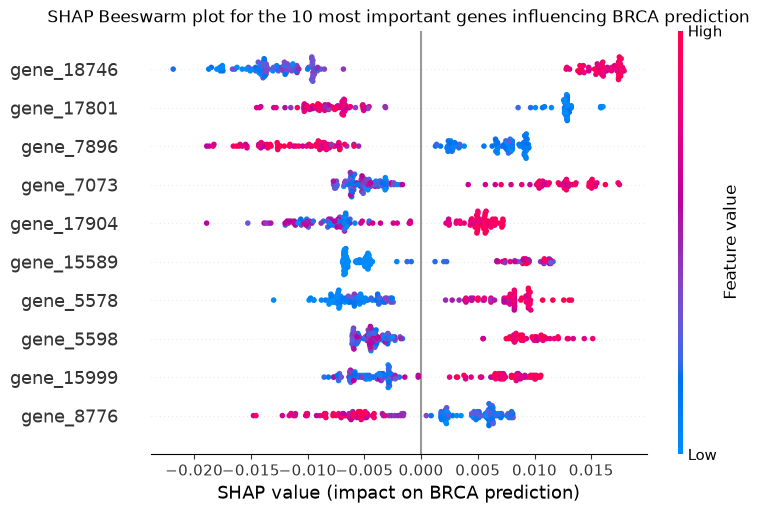

In [162]:
## Lets plot the BRCA beeplot
class_idx = list(rf_model.classes_).index("BRCA")
brca_shap = shap_values[:, :, class_idx]
shap.plots.beeswarm(
    brca_shap,
    max_display=10,
    group_remaining_features=False,
    show=False
)
plt.title('SHAP Beeswarm plot for the 10 most important genes influencing BRCA prediction')
plt.xlabel('SHAP value (impact on BRCA prediction)')
plt.show()

The beeswarm plot summarizes the influence of the 10 most informative genes for BRCA prediction across all patients. Each point represents one patient with color indicating the gene expression (red = higher expression). The highest ranked feature, gene_18746, predicted higher chance of BRCA cancer type with higher expression, while lower expression decreased BRCA prediction probability. 